In [38]:
import sys
sys.executable
print(sys.executable)

version = sys.version
print(version)


c:\kalpesh\1.ITvedant\2.ML projects\IEX_Carbon_Credit_ML_Project\venv\Scripts\python.exe
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


# IEX Trading Intelligence DATA SCIENCE RESEARCH

#### 1. INTRODUCTION

Project Objective

The objective of this machine learning system is to predict the performance of Instagram posts and support data-driven content planning for Graphura.
Each post is classified into one of three performance categories based on historical engagement rate thresholds:

-High Performance
-Medium Performance
-Low Performance

## 1. Importing essential python libraries 

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Loading

In [40]:
from sqlalchemy import create_engine

In [41]:
username = "root"
password = "root"
host = "localhost"
port = "3306"
database = "Carbon_Trading_DB"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [42]:
engine.connect()

In [43]:
df = pd.read_sql("SELECT * FROM carbon_data", engine)
df.head()

,Company_ID,Industry_Type,Date,Energy_Demand_MWh,Fuel_Type,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Credits_Traded_tCO2,Verification_Status,Compliance_Cost_USD,Optimization_Scenario,Carbon_Cost_Savings_USD,Transaction_Type
0,C099,Manufacturing,2025-03-20,2523.15,Renewable,1532.65,1428.65,35.00,59.0,DISPUTED,9574.32,High_Demand,1391.01,Sell
1,C015,Cement,2024-01-12,NaN,Renewable,1205.54,1228.54,34.69,59.0,Disputed,5714.48,Price_Surge,2812.27,Buy
2,C047,Manufacturing,2024-08-28,977.27,Renewable,731.40,721.40,35.00,61.0,Verified,15937.79,Price_Surge,570.26,Hold
3,C090,nan,2024-01-11,NaN,Natural Gas,1396.17,1258.17,33.93,139.0,Verified,8376.35,Low_Demand,1606.84,buy
4,C095,Energy,2024-11-03,NaN,MIXED FUEL,1485.77,1533.77,33.71,140.0,Disputed,11344.26,Low_Demand,1677.89,Buy


## 3. Data Cleaning & Preprocessing

In [44]:
df.info()
df.isnull().sum()

df.columns = (df.columns.str.strip().str.lower().str.title())

obj_cols = df.select_dtypes(include="object").columns

df[obj_cols] = df[obj_cols].apply(
    lambda col: col.astype(str)
                   .str.strip()
                   .str.lower()
                   .str.title()
)

for col in obj_cols:
    # remove spaces
    df[col] = df[col].astype(str).str.strip()
    
    # convert fake missing values to real NaN
    df[col] = df[col].replace(
        ["nan", "Nan", "NAN", "None","Unknown", "UNKNOWN", "null", ""],
        np.nan
    )
    
    # fill using mode
    df[col] = df[col].fillna(df[col].mode()[0])



# --------------------------------------------------
# Select numeric columns
# --------------------------------------------------
num_cols = df.select_dtypes(include=["number"]).columns

# --------------------------------------------------
# Convert fake numeric strings to NaN (if any)
# --------------------------------------------------
for col in num_cols:
    
    # Ensure numeric type (coerce converts invalid values → NaN)
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Replace infinite values (important for divisions)
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    
    # Fill missing values using MEDIAN (robust to outliers)
    df[col] = df[col].fillna(df[col].median())



df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4511 entries, 0 to 4510
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Company_ID               4511 non-null   object 
 1   Industry_Type            4511 non-null   object 
 2   Date                     4511 non-null   object 
 3   Energy_Demand_MWh        4423 non-null   float64
 4   Fuel_Type                4511 non-null   object 
 5   Emission_Produced_tCO2   4511 non-null   float64
 6   Emission_Allowance_tCO2  4511 non-null   float64
 7   Carbon_Price_USD_per_t   4425 non-null   float64
 8   Credits_Traded_tCO2      4511 non-null   float64
 9   Verification_Status      4511 non-null   object 
 10  Compliance_Cost_USD      4511 non-null   float64
 11  Optimization_Scenario    4511 non-null   object 
 12  Carbon_Cost_Savings_USD  4511 non-null   float64
 13  Transaction_Type         4511 non-null   object 
dtypes: float64(7), object(7)

,Company_Id,Industry_Type,Date,Energy_Demand_Mwh,Fuel_Type,Emission_Produced_Tco2,Emission_Allowance_Tco2,Carbon_Price_Usd_Per_T,Credits_Traded_Tco2,Verification_Status,Compliance_Cost_Usd,Optimization_Scenario,Carbon_Cost_Savings_Usd,Transaction_Type
0,C099,Manufacturing,2025-03-20,2523.15,Renewable,1532.65,1428.65,35.00,59.0,Disputed,9574.32,High_Demand,1391.01,Sell
1,C015,Cement,2024-01-12,1747.79,Renewable,1205.54,1228.54,34.69,59.0,Disputed,5714.48,Price_Surge,2812.27,Buy
2,C047,Manufacturing,2024-08-28,977.27,Renewable,731.40,721.40,35.00,61.0,Verified,15937.79,Price_Surge,570.26,Hold
3,C090,Manufacturing,2024-01-11,1747.79,Natural Gas,1396.17,1258.17,33.93,139.0,Verified,8376.35,Low_Demand,1606.84,Buy
4,C095,Energy,2024-11-03,1747.79,Mixed Fuel,1485.77,1533.77,33.71,140.0,Disputed,11344.26,Low_Demand,1677.89,Buy


In [45]:
from sklearn.impute import SimpleImputer

# Convert numeric columns stored as object
numeric_cols = ["Energy_Demand_Mwh","Carbon_Price_Usd_Per_T"]

for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4511 entries, 0 to 4510
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Company_Id               4511 non-null   object 
 1   Industry_Type            4511 non-null   object 
 2   Date                     4511 non-null   object 
 3   Energy_Demand_Mwh        4511 non-null   float64
 4   Fuel_Type                4511 non-null   object 
 5   Emission_Produced_Tco2   4511 non-null   float64
 6   Emission_Allowance_Tco2  4511 non-null   float64
 7   Carbon_Price_Usd_Per_T   4511 non-null   float64
 8   Credits_Traded_Tco2      4511 non-null   float64
 9   Verification_Status      4511 non-null   object 
 10  Compliance_Cost_Usd      4511 non-null   float64
 11  Optimization_Scenario    4511 non-null   object 
 12  Carbon_Cost_Savings_Usd  4511 non-null   float64
 13  Transaction_Type         4511 non-null   object 
dtypes: float64(7), object(7)

In [46]:
df.drop(columns=['Company_Id', 'Date'], inplace=True)

## 4.Feature Engineering`

In [47]:
data.head()

,Industry_Type,Energy_Demand_Mwh,Fuel_Type,Emission_Produced_Tco2,Emission_Allowance_Tco2,Carbon_Price_Usd_Per_T,Credits_Traded_Tco2,Verification_Status,Compliance_Cost_Usd,Optimization_Scenario,Carbon_Cost_Savings_Usd,Transaction_Type,Emission_Gap,Compliance_Pressure,Cost_per_MWh,Fuel_Carbon_Factor
0,Manufacturing,2523.15,Renewable,1532.65,1428.65,35.00,59.0,Disputed,9574.32,High_Demand,1391.01,2,104.0,3640.00,3.794590,0.25
1,Cement,1747.79,Renewable,1205.54,1228.54,34.69,59.0,Disputed,5714.48,Price_Surge,2812.27,0,-23.0,-797.87,3.269546,0.25
2,Manufacturing,977.27,Renewable,731.40,721.40,35.00,61.0,Verified,15937.79,Price_Surge,570.26,1,10.0,350.00,16.308482,0.25
3,Manufacturing,1747.79,Natural Gas,1396.17,1258.17,33.93,139.0,Verified,8376.35,Low_Demand,1606.84,0,138.0,4682.34,4.792538,0.50
4,Energy,1747.79,Mixed Fuel,1485.77,1533.77,33.71,140.0,Disputed,11344.26,Low_Demand,1677.89,0,-48.0,-1618.08,6.490631,0.75


In [48]:
# ===============================
# PART 1 : FEATURE ENGINEERING
# ===============================

import numpy as np
import pandas as pd

EPS = 1e-6

# -------------------------------
# 1. Emission Gap
# -------------------------------
df["Emission_Gap"] = (
    df["Emission_Produced_Tco2"]
    - df["Emission_Allowance_Tco2"]
)

# -------------------------------
# 2. Compliance Pressure
# -------------------------------
df["Compliance_Pressure"] = (
    df["Emission_Gap"]
    * df["Carbon_Price_Usd_Per_T"]
)

# -------------------------------
# 3. Cost per Energy Unit
# -------------------------------
df["Cost_per_MWh"] = np.where(
    df["Energy_Demand_Mwh"] > 0,
    df["Compliance_Cost_Usd"] /
    (df["Energy_Demand_Mwh"] + EPS),
    0
)

ratio_cols = ["Cost_per_MWh"]

for col in ratio_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

# -------------------------------
# 4. Fuel Carbon Factor
# -------------------------------
fuel_factor = {
    "Coal": 0.95,
    "Mixed Fuel": 0.75,
    "Natural Gas": 0.5,
    "Renewable": 0.25
}

df["Fuel_Carbon_Factor"] = (
    df["Fuel_Type"]
    .map(fuel_factor)
    .fillna(0.5)
)



# -------------------------------
# 5. Target Encoding
# -------------------------------
target = "Transaction_Type"

target_map = {
    "Buy": 0,
    "Hold": 1,
    "Sell": 2
}

df[target] = df[target].map(target_map)

# Feature Selection

In [49]:
# ===============================
# PART 2 : MODEL FEATURES
# ===============================

# Columns causing leakage
leakage_cols = [
    'Compliance_Cost_Usd',
    'Carbon_Cost_Savings_Usd'
]

# Numerical features (FIXED)
num_cols = [
    "Energy_Demand_Mwh",
    "Carbon_Price_Usd_Per_T",
    'Credits_Traded_Tco2',

    # Engineered Features
    "Emission_Gap",
    "Compliance_Pressure",
    "Cost_per_MWh",
    "Fuel_Carbon_Factor"
]

cat_cols = ["Optimization_Scenario"]


target = "Transaction_Type"

In [50]:
from sklearn.model_selection import train_test_split

xc = df[num_cols + cat_cols]

yc = df[target]

xctrain, xctest, yctrain, yctest = train_test_split(xc,yc,test_size=0.2,random_state=42,stratify=yc)


print("Feature shape:", xc.shape)
print("Target shape:", yc.shape)


Feature shape: (4511, 8)
Target shape: (4511,)


In [51]:
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder


# ---------- Numerical Pipeline ----------
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # better for skewed data
    ("scaler", RobustScaler())
])


# ---------- Categorical Pipeline ----------
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])



# ---------- Preprocessor ----------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ],
    remainder="drop"   # ✅ MUST be inside ColumnTransformer
)

In [52]:
xctrain_processed = preprocessor.fit_transform(xctrain)
xctest_processed = preprocessor.transform(xctest)

In [53]:


xctrain[num_cols].describe(percentiles=[0.01,0.05,0.95,0.99])

,Energy_Demand_Mwh,Carbon_Price_Usd_Per_T,Credits_Traded_Tco2,Emission_Gap,Compliance_Pressure,Cost_per_MWh,Fuel_Carbon_Factor
count,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000
mean,1760.293952,27.590338,109.121397,0.589155,17.168452,8.700930,0.652106
std,708.583753,4.307206,51.390579,115.537773,3224.872315,5.488987,0.236037
min,500.650000,20.000000,20.000000,-200.000000,-6782.710000,2.081083,0.250000
1%,522.535900,20.160000,21.070000,-197.000000,-6067.015000,2.148032,0.250000
5%,621.652500,20.753500,28.000000,-182.000000,-5094.844000,2.762055,0.250000
50%,1747.790000,27.525000,109.000000,4.000000,101.280000,7.190212,0.750000
95%,2887.990500,34.196500,189.000000,179.000000,5135.016500,20.032388,0.950000
99%,2973.604800,34.839300,197.000000,196.000000,6157.500800,30.009416,0.950000
max,2999.510000,35.000000,200.000000,200.000000,6932.000000,30.016937,0.950000


In [54]:
print(df["Transaction_Type"].value_counts(normalize=True))

Transaction_Type
1    0.414099
0    0.324540
2    0.261361
Name: proportion, dtype: float64


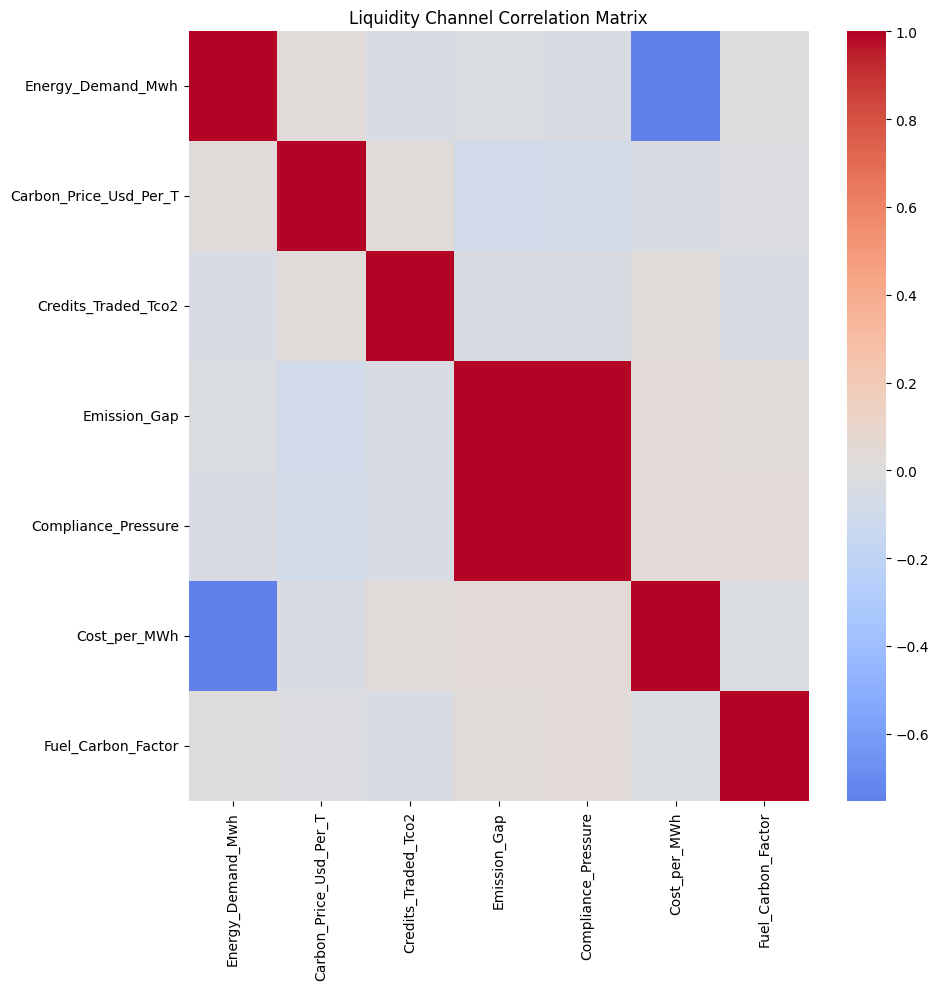

In [55]:
corr = xctest.select_dtypes(include=["int64", "float64"]) \
           .corr()


plt.figure(figsize=(10,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Liquidity Channel Correlation Matrix")
plt.show()

# CLASSIFICATION MODELS (post performance category)

#### Model Training, Model Evaluation & Model Training

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, xctest, yctest, name):

    # ---- labels for classes ----
    labels = ['Buy', 'Sell', 'Hold']   # change order if needed

    preds = model.predict(xctest)
    acc = accuracy_score(yctest, preds)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(yctest, preds, target_names=labels))

    # Confusion Matrix
    cm = confusion_matrix(yctest, preds)
    print("Confusion Matrix:")
    print(cm)

    # ---- Plot ----
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.show()

    return acc

In [57]:
from sklearn.pipeline import Pipeline

## 1. Logistic Regression


Logistic Regression
Accuracy: 0.5991140642303433
              precision    recall  f1-score   support

         Buy       0.53      0.48      0.50       293
        Sell       0.61      0.63      0.62       374
        Hold       0.65      0.71      0.68       236

    accuracy                           0.60       903
   macro avg       0.60      0.60      0.60       903
weighted avg       0.60      0.60      0.60       903

Confusion Matrix:
[[140 104  49]
 [ 99 234  41]
 [ 24  45 167]]


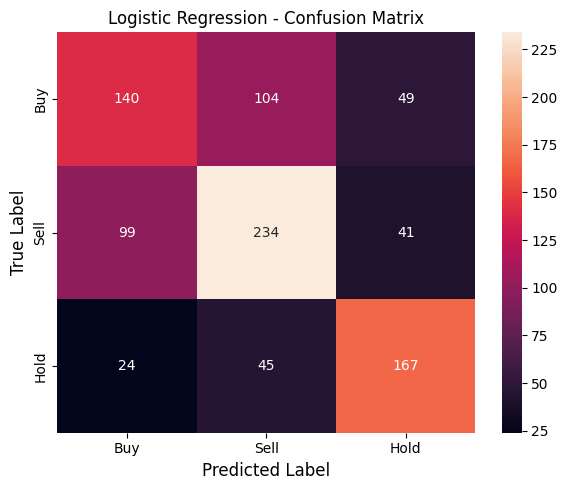

0.5991140642303433

In [58]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=200,
        C=10,
        n_jobs=-1,
        class_weight= None,  # no class weighting   
        solver="lbfgs",
        random_state=42
    ))
])

best_log = lr_pipe.fit(xctrain, yctrain)

evaluate_model(best_log, xctest, yctest, "Logistic Regression")

### 2. K-Nearest Neighbors


KNN
Accuracy: 0.6489479512735327
              precision    recall  f1-score   support

         Buy       0.60      0.45      0.51       293
        Sell       0.67      0.76      0.71       374
        Hold       0.66      0.72      0.69       236

    accuracy                           0.65       903
   macro avg       0.64      0.64      0.64       903
weighted avg       0.64      0.65      0.64       903

Confusion Matrix:
[[132 103  58]
 [ 59 283  32]
 [ 29  36 171]]


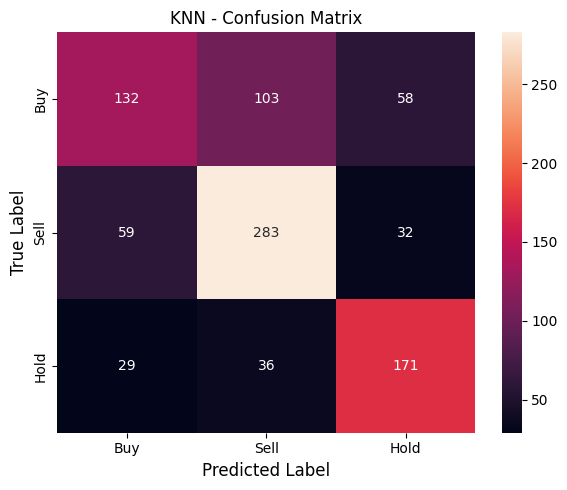

0.6489479512735327

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
    ))
])

best_knn = knn_pipe.fit(xctrain, yctrain)

evaluate_model(best_knn, xctest, yctest, "KNN")

### 3. Naive Bayes


Gaussian Naive Bayes
Accuracy: 0.6090808416389811
              precision    recall  f1-score   support

         Buy       0.54      0.49      0.52       293
        Sell       0.72      0.51      0.60       374
        Hold       0.58      0.90      0.71       236

    accuracy                           0.61       903
   macro avg       0.61      0.64      0.61       903
weighted avg       0.62      0.61      0.60       903

Confusion Matrix:
[[145  60  88]
 [116 192  66]
 [  8  15 213]]


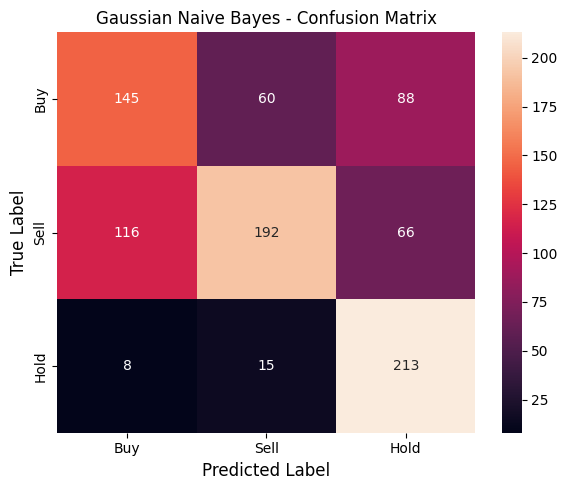

0.6090808416389811

In [60]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

gnb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB(var_smoothing=1e-09))
])

# Train
best_gnb = gnb_pipe.fit(xctrain, yctrain)

# Evaluate
evaluate_model(best_gnb, xctest, yctest, "Gaussian Naive Bayes")

### 4. Decision Tree


Decision Tree
Accuracy: 0.7718715393133998
              precision    recall  f1-score   support

         Buy       0.76      0.75      0.75       293
        Sell       0.83      0.86      0.84       374
        Hold       0.69      0.67      0.68       236

    accuracy                           0.77       903
   macro avg       0.76      0.76      0.76       903
weighted avg       0.77      0.77      0.77       903

Confusion Matrix:
[[220  38  35]
 [ 20 320  34]
 [ 50  29 157]]


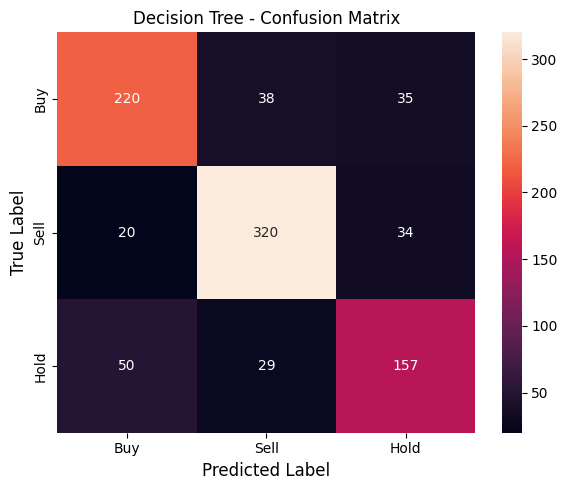

0.7718715393133998

In [61]:
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=15,
        min_samples_leaf=5,
        random_state=42
    ))
])

best_dt = dt_pipe.fit(xctrain, yctrain)

evaluate_model(best_dt, xctest, yctest, "Decision Tree")

### 5. Support Vector Machine(SVC)


SVM
Accuracy: 0.6500553709856035
              precision    recall  f1-score   support

         Buy       0.63      0.40      0.49       293
        Sell       0.68      0.74      0.71       374
        Hold       0.63      0.83      0.71       236

    accuracy                           0.65       903
   macro avg       0.64      0.65      0.64       903
weighted avg       0.65      0.65      0.64       903

Confusion Matrix:
[[117 108  68]
 [ 51 275  48]
 [ 18  23 195]]


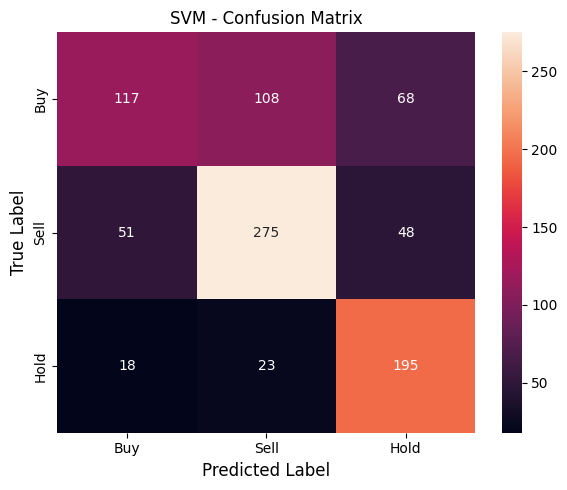

0.6500553709856035

In [62]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True
    ))
])

best_svc = svm_pipe.fit(xctrain, yctrain)

evaluate_model(best_svc, xctest, yctest, "SVM")

### 6. Random Forest


Random Forest
Accuracy: 0.778516057585825
              precision    recall  f1-score   support

         Buy       0.80      0.67      0.73       293
        Sell       0.83      0.89      0.86       374
        Hold       0.68      0.74      0.71       236

    accuracy                           0.78       903
   macro avg       0.77      0.77      0.76       903
weighted avg       0.78      0.78      0.78       903

Confusion Matrix:
[[195  48  50]
 [  7 334  33]
 [ 42  20 174]]


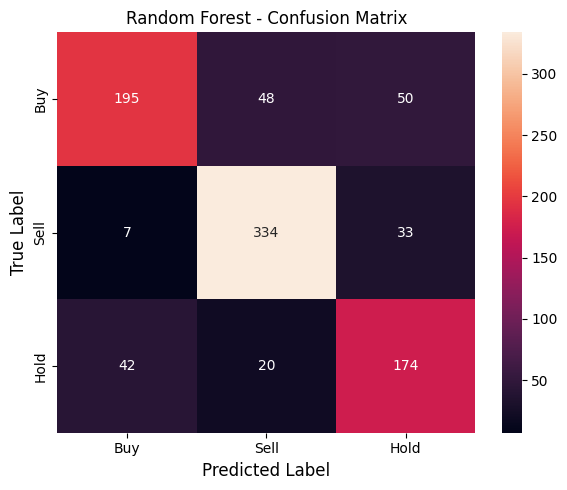

0.778516057585825

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight=None,  # no class weighting    
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

best_rf = rf_pipe.fit(xctrain, yctrain)

evaluate_model(best_rf, xctest, yctest, "Random Forest")

### 7. Gradient Boosting


Gradient Boosting
Accuracy: 0.8039867109634552
              precision    recall  f1-score   support

         Buy       0.79      0.76      0.77       293
        Sell       0.85      0.91      0.88       374
        Hold       0.73      0.69      0.71       236

    accuracy                           0.80       903
   macro avg       0.79      0.79      0.79       903
weighted avg       0.80      0.80      0.80       903

Confusion Matrix:
[[222  29  42]
 [ 16 341  17]
 [ 44  29 163]]


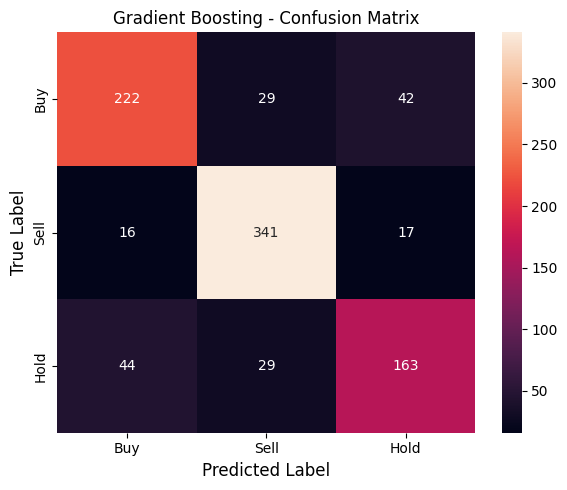

0.8039867109634552

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

best_gb = gb_pipe.fit(xctrain, yctrain)

evaluate_model(best_gb, xctest, yctest, "Gradient Boosting")

### 8. XG Boost


XGBoost
Accuracy: 0.8017718715393134
              precision    recall  f1-score   support

         Buy       0.79      0.77      0.78       293
        Sell       0.89      0.89      0.89       374
        Hold       0.68      0.69      0.69       236

    accuracy                           0.80       903
   macro avg       0.79      0.79      0.79       903
weighted avg       0.80      0.80      0.80       903

Confusion Matrix:
[[227  18  48]
 [ 12 333  29]
 [ 47  25 164]]


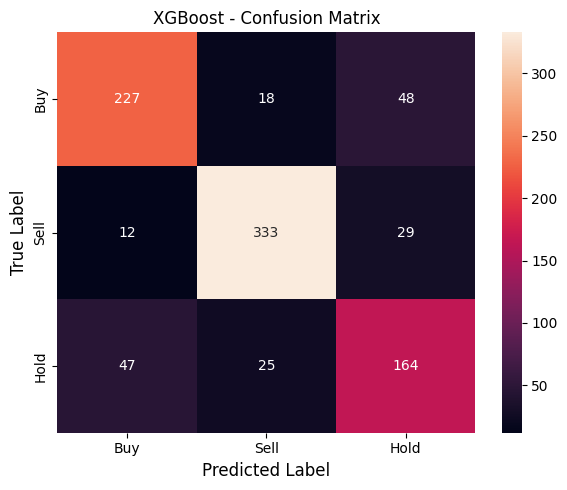

0.8017718715393134

In [65]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.1,
        reg_lambda=2,
        reg_alpha=0.2,
        eval_metric="mlogloss",
        tree_method="hist",   # faster training
        random_state=42
    ))
])

best_xgb = xgb_pipe.fit(xctrain, yctrain)

evaluate_model(best_xgb, xctest, yctest, "XGBoost")

In [66]:
from sklearn.metrics import accuracy_score

final_results = pd.DataFrame([
    ["Logistic Regression", accuracy_score(yctest, best_log.predict(xctest))],
    ["KNN", accuracy_score(yctest, best_knn.predict(xctest))],
    ["Decision Tree", accuracy_score(yctest, best_dt.predict(xctest))],
    ["Random Forest", accuracy_score(yctest, best_rf.predict(xctest))],
    ["Gradient Boosting", accuracy_score(yctest, best_gb.predict(xctest))],
    ["SVC", accuracy_score(yctest, best_svc.predict(xctest))],
    ["GaussianNB", accuracy_score(yctest, best_gnb.predict(xctest))],
    ["XGBoost", accuracy_score(yctest, best_xgb.predict(xctest))]
], columns=["Model", "Accuracy"])

final_results = final_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Accuracy
0,Gradient Boosting,0.803987
1,XGBoost,0.801772
2,Random Forest,0.778516
3,Decision Tree,0.771872
4,SVC,0.650055
5,KNN,0.648948
6,GaussianNB,0.609081
7,Logistic Regression,0.599114


In [67]:

best_model = best_xgb  # XGBoost performed best in this example

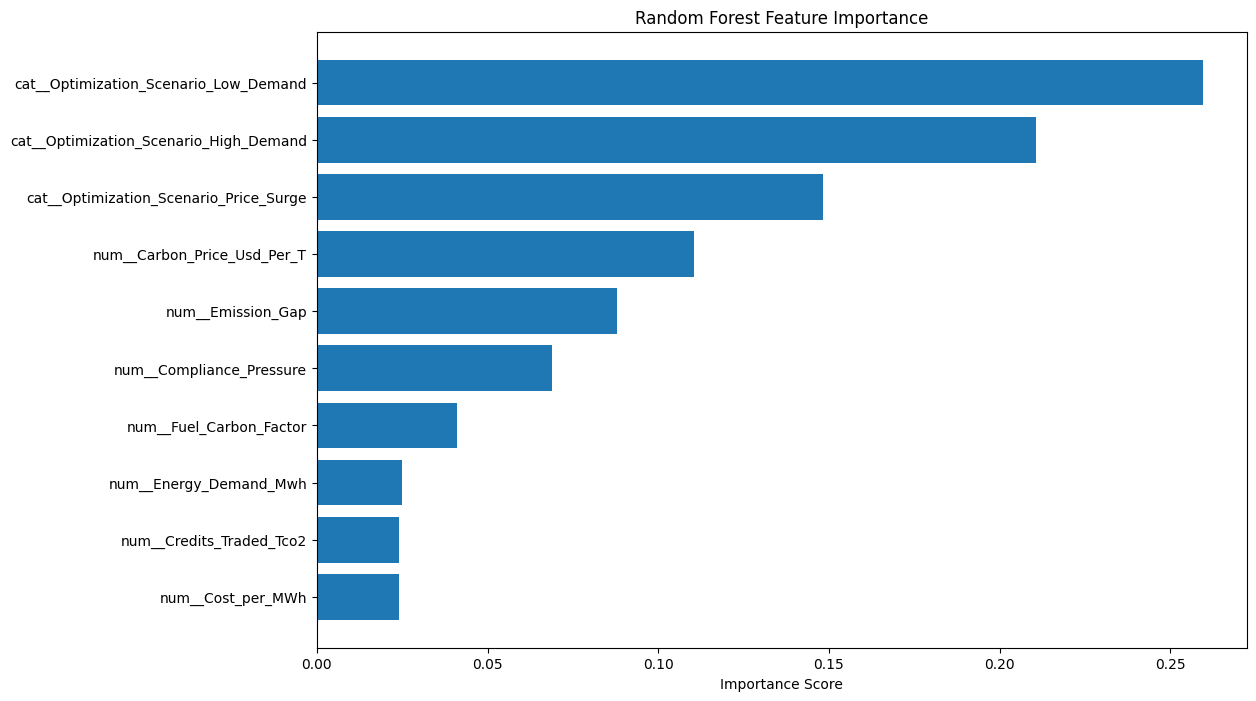

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Extract model inside pipeline
rf_model = best_model.named_steps["model"]

# 2️⃣ Get feature importances
importance = rf_model.feature_importances_

# 3️⃣ Get feature names AFTER preprocessing
preprocessor = best_model.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()

# 4️⃣ Sort features
indices = np.argsort(importance)

# 5️⃣ Plot
plt.figure(figsize=(12,8))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()


## CLASSIFICATION MANUAL TESTING (Risk Regime)

🟢 0 = Buy  → Compliance Deficit (Purchase Required)

🟡 1 = Hold → Compliance Balanced (No Action)

🔴 2 = Sell → Compliance Surplus (Credits Available)

# Deployment 

In [69]:
vvv EXPECTED_COLUMNS = xctrain.columns.tolist()
def safe_input(df):
    for col in EXPECTED_COLUMNS:
        if col not in df:
            df[col] = None
    return df[EXPECTED_COLUMNS]

SyntaxError: invalid syntax (3923571929.py, line 1)

# Saving the model for deployment 

In [ ]:
import os, joblib

print(os.getcwd())
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "best_model_pipeline.joblib")
print(os.listdir("models"))

c:\kalpesh\1.ITvedant\2.ML projects\IEX_Carbon_Credit_ML_Project\notebooks
[]


In [ ]:
import sklearn
print(sklearn.__version__)

1.3.2


In [ ]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [ ]:
import sys, sklearn, joblib

print(sys.version)
print(sklearn.__version__)

joblib.dump(best_model, "best_model_pipeline.joblib")


3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
1.3.2


['best_model_pipeline.joblib']